# 09: Verbal vs Nominal vs Joint MAL Effect Comparison

This notebook compares the Menzerath-Altmann Law (MAL) effect across different syntactic contexts:

1. **Verbal heads** (VERB only) - traditional clause-level MAL
2. **Nominal heads** (NOUN, PROPN) - noun phrase-level MAL  
3. **Joint** (VERB + NOUN + PROPN) - combined analysis

For each context, we compute:
- MAL_n scores (total, left, right dependents)
- Cross-linguistic compliance rates
- Permutation significance tests
- Statistical comparison between contexts

## 1. Setup and Data Loading

In [1]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm import tqdm

# Plotting settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

DATA_DIR = 'data'

print("Setup complete!")

Setup complete!


In [3]:
# Load all three head type datasets
head_types = ['verb', 'noun', 'all']

average_sizes = {}
position2num = {}
position2sizes = {}

for ht in head_types:
    with open(os.path.join(DATA_DIR, f'all_langs_average_sizes_{ht}.pkl'), 'rb') as f:
        average_sizes[ht] = pickle.load(f)
    with open(os.path.join(DATA_DIR, f'all_langs_position2num_{ht}.pkl'), 'rb') as f:
        position2num[ht] = pickle.load(f)
    with open(os.path.join(DATA_DIR, f'all_langs_position2sizes_{ht}.pkl'), 'rb') as f:
        position2sizes[ht] = pickle.load(f)
    
    print(f"Loaded {ht}: {len(average_sizes[ht])} languages")

# Load language metadata
import data_utils
metadata = data_utils.load_metadata(os.path.join(DATA_DIR, 'metadata.pkl'))
langNames = metadata['langNames']

# Load family info from metadata (langnameGroup has family info)
langnameGroup = metadata.get('langnameGroup', {})
# Create langFamily dict: lang_code -> family
langFamily = {}
for lang, group_info in langnameGroup.items():
    if isinstance(group_info, dict) and 'family' in group_info:
        langFamily[lang] = group_info['family']
    elif isinstance(group_info, str):
        langFamily[lang] = group_info
    else:
        langFamily[lang] = 'Unknown'

print(f"\nLoaded metadata for {len(langNames)} languages")
print(f"Family info available for {len(langFamily)} languages")

Loaded verb: 186 languages
Loaded noun: 186 languages
Loaded all: 186 languages
Loaded metadata from data/metadata.pkl

Loaded metadata for 187 languages
Family info available for 188 languages


## 2. MAL_n Computation Function

In [6]:
def compute_mal_n(average_sizes_data, position2num_data, min_positions=3, max_position=5, side='left'):
    """
    Compute MAL_n (slope of log-average-size vs position) for all languages.
    
    Parameters
    ----------
    side : str
        'left', 'right', or 'global_totleft' / 'global_totright' for global positions
    
    Returns dict: lang -> {'mal_n': slope, 'r_squared': r2, 'n_positions': n}
    """
    results = {}
    
    for lang, sizes in average_sizes_data.items():
        # Get average sizes for positions 1..max_position
        positions = []
        log_sizes = []
        
        for pos in range(1, max_position + 1):
            # Keys are like: average_totleft_1, average_totright_1, average_global_totleft_1
            key = f'average_tot{side}_{pos}'
            if key in sizes and sizes[key] > 0:
                # Check we have enough data points
                num_key = f'{side}_{pos}'
                if lang in position2num_data and num_key in position2num_data[lang]:
                    if position2num_data[lang][num_key] >= 10:  # Minimum threshold
                        positions.append(pos)
                        log_sizes.append(sizes[key])  # Already log-transformed
        
        if len(positions) >= min_positions:
            # Linear regression
            slope, intercept, r_value, p_value, std_err = stats.linregress(positions, log_sizes)
            results[lang] = {
                'mal_n': slope,
                'r_squared': r_value ** 2,
                'n_positions': len(positions),
                'p_value': p_value
            }
    
    return results


def compute_mal_combined(average_sizes_data, position2num_data, min_positions=3, max_position=5):
    """
    Compute MAL combining left and right positions (positions 1..N from verb).
    Uses left_1, left_2, ... and right_1, right_2 combined.
    """
    results = {}
    
    for lang, sizes in average_sizes_data.items():
        positions = []
        log_sizes = []
        
        # Combine left and right into single position sequence
        for side in ['left', 'right']:
            for pos in range(1, max_position + 1):
                key = f'{side}_{pos}'
                if key in sizes and sizes[key] > 0:
                    num_key = f'{side}_{pos}'
                    if lang in position2num_data and num_key in position2num_data[lang]:
                        if position2num_data[lang][num_key] >= 10:
                            positions.append(pos)
                            log_sizes.append(sizes[key])  # Log-averaged size
        
        if len(positions) >= min_positions:
            slope, intercept, r_value, p_value, std_err = stats.linregress(positions, log_sizes)
            results[lang] = {
                'mal_n': slope,
                'r_squared': r_value ** 2,
                'n_positions': len(positions),
                'p_value': p_value
            }
    
    return results


def compute_mal_directional(average_sizes_data, position2num_data, direction='left', min_positions=2, max_position=4):
    """
    Compute MAL for left or right dependents only.
    Uses direct positional keys: left_1, left_2, right_1, right_2, etc.
    """
    results = {}
    
    for lang, sizes in average_sizes_data.items():
        positions = []
        log_sizes = []
        
        for pos in range(1, max_position + 1):
            key = f'{direction}_{pos}'
            if key in sizes and sizes[key] > 0:
                num_key = f'{direction}_{pos}'
                if lang in position2num_data and num_key in position2num_data[lang]:
                    if position2num_data[lang][num_key] >= 10:
                        positions.append(pos)
                        log_sizes.append(sizes[key])
        
        if len(positions) >= min_positions:
            slope, intercept, r_value, p_value, std_err = stats.linregress(positions, log_sizes)
            results[lang] = {
                'mal_n': slope,
                'r_squared': r_value ** 2,
                'n_positions': len(positions),
                'p_value': p_value
            }
    
    return results

print("MAL computation functions defined.")

MAL computation functions defined.


## 3. Compute MAL Scores for All Head Types

In [7]:
# Compute combined MAL (left + right positions) for each head type
mal_total = {}
for ht in head_types:
    mal_total[ht] = compute_mal_combined(average_sizes[ht], position2num[ht])
    print(f"{ht.upper()}: {len(mal_total[ht])} languages with valid MAL_n (combined L+R)")

# Compute directional MAL
mal_left = {}
mal_right = {}
for ht in head_types:
    mal_left[ht] = compute_mal_directional(average_sizes[ht], position2num[ht], direction='left')
    mal_right[ht] = compute_mal_directional(average_sizes[ht], position2num[ht], direction='right')
    print(f"{ht.upper()} left: {len(mal_left[ht])}, right: {len(mal_right[ht])}")

VERB: 175 languages with valid MAL_n (combined L+R)
NOUN: 149 languages with valid MAL_n (combined L+R)
ALL: 178 languages with valid MAL_n (combined L+R)
VERB left: 175, right: 146
NOUN left: 143, right: 122
ALL left: 178, right: 148


In [8]:
# Create summary DataFrame
all_langs = set()
for ht in head_types:
    all_langs.update(mal_total[ht].keys())

summary_data = []
for lang in all_langs:
    row = {
        'lang': lang,
        'name': langNames.get(lang, lang),
        'family': langFamily.get(lang, 'Unknown')
    }
    for ht in head_types:
        if lang in mal_total[ht]:
            row[f'mal_{ht}'] = mal_total[ht][lang]['mal_n']
            row[f'r2_{ht}'] = mal_total[ht][lang]['r_squared']
        else:
            row[f'mal_{ht}'] = np.nan
            row[f'r2_{ht}'] = np.nan
    summary_data.append(row)

df_mal = pd.DataFrame(summary_data)
df_mal = df_mal.dropna(subset=[f'mal_{ht}' for ht in head_types], how='all')

print(f"Total languages in comparison: {len(df_mal)}")
print(f"\nLanguages with all three head types: {df_mal.dropna(subset=[f'mal_{ht}' for ht in head_types]).shape[0]}")

df_mal.head(10)

Total languages in comparison: 178

Languages with all three head types: 149


,lang,name,family,mal_verb,r2_verb,mal_noun,r2_noun,mal_all,r2_all
0,nl,Dutch,Unknown,0.161986,0.049959,0.323957,0.085428,0.211436,0.073276
1,tl,Tagalog,Unknown,0.329623,0.383216,0.973114,0.917012,0.160872,0.080590
2,lzh,ClassChinese,Unknown,-0.009658,0.000677,0.013255,0.014732,-0.000976,0.000007
3,cy,Welsh,Unknown,0.600450,0.285202,1.169865,0.476088,0.862703,0.485406
4,bm,Bambara,Unknown,0.577216,0.201938,NaN,NaN,0.631600,0.251505
5,ru,Russian,Unknown,0.215278,0.081434,0.176070,0.053783,0.203835,0.075224
6,tpn,Tupinambá,Unknown,0.116340,0.292009,0.065887,0.048759,0.115771,0.267550
7,en,English,Unknown,0.524433,0.283062,0.035137,0.002406,0.347047,0.159660
8,xav,Xavánte,Unknown,-0.020892,0.000756,0.037138,0.112542,0.030543,0.001445
9,id,Indonesian,Unknown,0.533893,0.224877,0.321966,0.308712,0.325349,0.267749


## 4. MAL Compliance Rates by Head Type

In [9]:
# Calculate compliance rates (negative slope = MAL compliance)
compliance_stats = {}

for ht in head_types:
    col = f'mal_{ht}'
    valid = df_mal[col].dropna()
    n_negative = (valid < 0).sum()
    n_total = len(valid)
    pct = 100 * n_negative / n_total if n_total > 0 else 0
    
    compliance_stats[ht] = {
        'n_languages': n_total,
        'n_compliant': n_negative,
        'pct_compliant': pct,
        'mean_slope': valid.mean(),
        'std_slope': valid.std()
    }
    
    print(f"{ht.upper():6s}: {n_negative:3d}/{n_total:3d} ({pct:5.1f}%) compliant | mean slope = {valid.mean():.3f} ± {valid.std():.3f}")

VERB  :  43/175 ( 24.6%) compliant | mean slope = 0.199 ± 0.388
NOUN  :  28/149 ( 18.8%) compliant | mean slope = 0.374 ± 0.536
ALL   :  34/178 ( 19.1%) compliant | mean slope = 0.244 ± 0.365


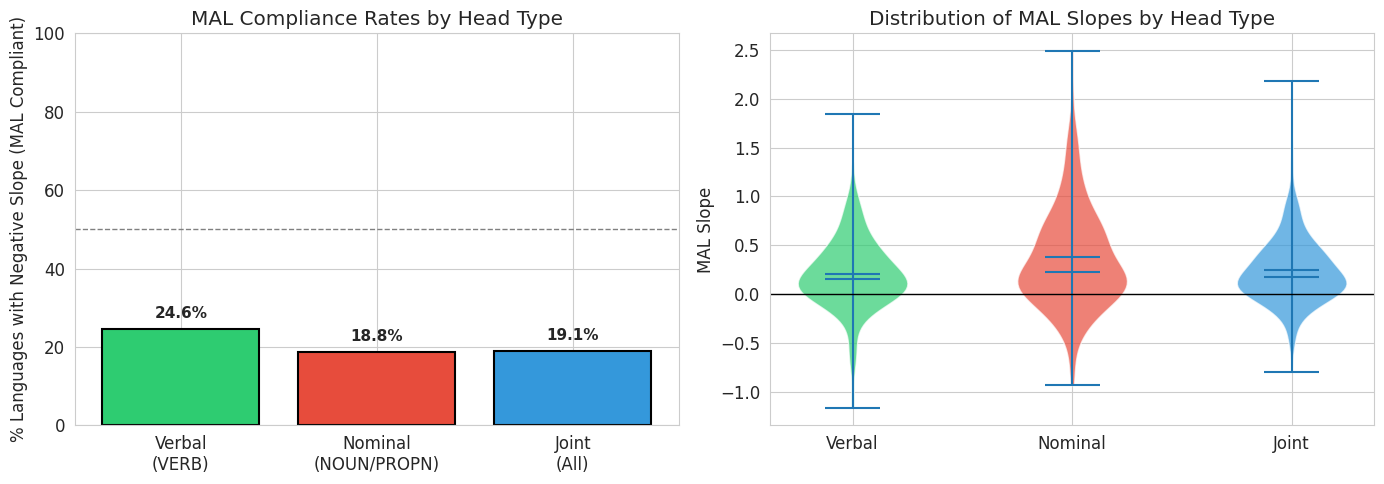

In [10]:
# Plot compliance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Bar chart of compliance rates
ax1 = axes[0]
labels = ['Verbal\n(VERB)', 'Nominal\n(NOUN/PROPN)', 'Joint\n(All)']
pcts = [compliance_stats[ht]['pct_compliant'] for ht in head_types]
colors = ['#2ecc71', '#e74c3c', '#3498db']

bars = ax1.bar(labels, pcts, color=colors, edgecolor='black', linewidth=1.5)
ax1.axhline(50, color='gray', linestyle='--', linewidth=1, label='50% (chance)')
ax1.set_ylabel('% Languages with Negative Slope (MAL Compliant)')
ax1.set_title('MAL Compliance Rates by Head Type')
ax1.set_ylim(0, 100)

# Add value labels
for bar, pct in zip(bars, pcts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Right: Violin plot of slopes
ax2 = axes[1]
violin_data = []
for ht in head_types:
    col = f'mal_{ht}'
    valid = df_mal[col].dropna()
    violin_data.append(valid.values)

parts = ax2.violinplot(violin_data, positions=[1, 2, 3], showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)

ax2.axhline(0, color='black', linestyle='-', linewidth=1)
ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(['Verbal', 'Nominal', 'Joint'])
ax2.set_ylabel('MAL Slope')
ax2.set_title('Distribution of MAL Slopes by Head Type')

plt.tight_layout()
plt.savefig('plots/mal_compliance_by_headtype.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Permutation Significance Tests

Test whether each language's MAL slope is significantly different from chance (shuffled baseline).

In [12]:
def permutation_test_mal(average_sizes_data, position2num_data, n_permutations=1000, alpha=0.05):
    """
    Perform permutation test for MAL significance.
    
    For each language, shuffle the size values and recompute slope.
    Compare observed slope to null distribution.
    """
    results = {}
    
    for lang in tqdm(average_sizes_data.keys(), desc="Permutation tests"):
        sizes = average_sizes_data[lang]
        
        # Get observed data points (combining left and right positions)
        positions = []
        log_sizes = []
        
        for side in ['left', 'right']:
            for pos in range(1, 6):
                key = f'{side}_{pos}'
                if key in sizes and sizes[key] > 0:
                    num_key = f'{side}_{pos}'
                    if lang in position2num_data and num_key in position2num_data[lang]:
                        if position2num_data[lang][num_key] >= 10:
                            positions.append(pos)
                            log_sizes.append(sizes[key])  # Already log-transformed
        
        if len(positions) < 3:
            continue
        
        positions = np.array(positions)
        log_sizes = np.array(log_sizes)
        
        # Observed slope
        observed_slope, _, _, _, _ = stats.linregress(positions, log_sizes)
        
        # Null distribution
        null_slopes = []
        for _ in range(n_permutations):
            shuffled = np.random.permutation(log_sizes)
            slope, _, _, _, _ = stats.linregress(positions, shuffled)
            null_slopes.append(slope)
        
        null_slopes = np.array(null_slopes)
        
        # Two-tailed p-value
        p_value = np.mean(np.abs(null_slopes) >= np.abs(observed_slope))
        
        results[lang] = {
            'observed_slope': observed_slope,
            'null_mean': null_slopes.mean(),
            'null_std': null_slopes.std(),
            'p_value': p_value,
            'significant': p_value < alpha,
            'effect_size': (observed_slope - null_slopes.mean()) / null_slopes.std() if null_slopes.std() > 0 else 0
        }
    
    return results

print("Permutation test function defined.")

Permutation test function defined.


In [13]:
# Run permutation tests for each head type
np.random.seed(42)  # For reproducibility

perm_results = {}
for ht in head_types:
    print(f"\nRunning permutation tests for {ht.upper()}...")
    perm_results[ht] = permutation_test_mal(
        average_sizes[ht], 
        position2num[ht],
        n_permutations=1000
    )


Running permutation tests for VERB...


Permutation tests: 100%|██████████| 186/186 [00:13<00:00, 13.30it/s]



Running permutation tests for NOUN...


Permutation tests: 100%|██████████| 186/186 [00:11<00:00, 15.79it/s]



Running permutation tests for ALL...


Permutation tests: 100%|██████████| 186/186 [00:14<00:00, 13.21it/s]


In [14]:
# Summarize significance results
print("\n" + "="*70)
print("SIGNIFICANCE SUMMARY (p < 0.05)")
print("="*70)

sig_summary = {}
for ht in head_types:
    results = perm_results[ht]
    n_total = len(results)
    n_sig = sum(1 for r in results.values() if r['significant'])
    n_sig_negative = sum(1 for r in results.values() if r['significant'] and r['observed_slope'] < 0)
    
    mean_effect = np.mean([r['effect_size'] for r in results.values()])
    
    sig_summary[ht] = {
        'n_total': n_total,
        'n_significant': n_sig,
        'n_sig_negative': n_sig_negative,
        'pct_significant': 100 * n_sig / n_total,
        'pct_sig_negative': 100 * n_sig_negative / n_total,
        'mean_effect_size': mean_effect
    }
    
    print(f"\n{ht.upper():10s}:")
    print(f"  Languages tested: {n_total}")
    print(f"  Significant MAL: {n_sig} ({100*n_sig/n_total:.1f}%)")
    print(f"  Significant NEGATIVE (MAL compliant): {n_sig_negative} ({100*n_sig_negative/n_total:.1f}%)")
    print(f"  Mean effect size (Cohen's d): {mean_effect:.2f}")


SIGNIFICANCE SUMMARY (p < 0.05)

VERB      :
  Languages tested: 175
  Significant MAL: 19 (10.9%)
  Significant NEGATIVE (MAL compliant): 0 (0.0%)
  Mean effect size (Cohen's d): 0.68

NOUN      :
  Languages tested: 149
  Significant MAL: 15 (10.1%)
  Significant NEGATIVE (MAL compliant): 0 (0.0%)
  Mean effect size (Cohen's d): 0.83

ALL       :
  Languages tested: 178
  Significant MAL: 23 (12.9%)
  Significant NEGATIVE (MAL compliant): 0 (0.0%)
  Mean effect size (Cohen's d): 0.85


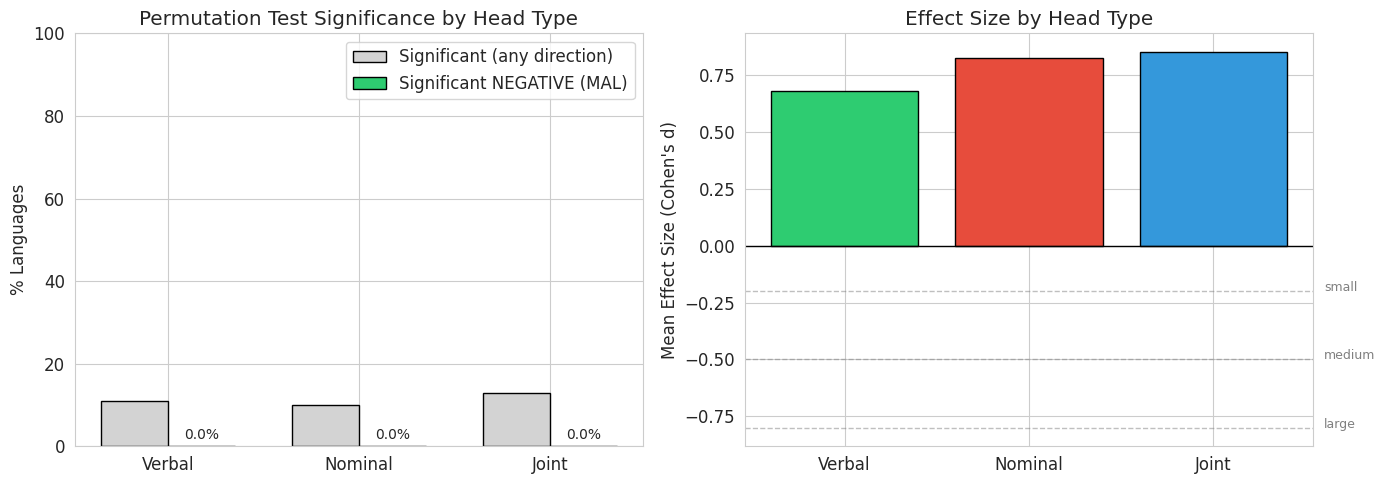

In [15]:
# Visualize significance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Significance rates
ax1 = axes[0]
labels = ['Verbal', 'Nominal', 'Joint']
pct_sig = [sig_summary[ht]['pct_significant'] for ht in head_types]
pct_sig_neg = [sig_summary[ht]['pct_sig_negative'] for ht in head_types]
colors = ['#2ecc71', '#e74c3c', '#3498db']

x = np.arange(len(labels))
width = 0.35

bars1 = ax1.bar(x - width/2, pct_sig, width, label='Significant (any direction)', color='lightgray', edgecolor='black')
bars2 = ax1.bar(x + width/2, pct_sig_neg, width, label='Significant NEGATIVE (MAL)', color=colors, edgecolor='black')

ax1.set_ylabel('% Languages')
ax1.set_title('Permutation Test Significance by Head Type')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend()
ax1.set_ylim(0, 100)

# Add value labels
for bar, val in zip(bars2, pct_sig_neg):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

# Right: Effect sizes
ax2 = axes[1]
effect_sizes = [sig_summary[ht]['mean_effect_size'] for ht in head_types]
bars = ax2.bar(labels, effect_sizes, color=colors, edgecolor='black')
ax2.axhline(0, color='black', linestyle='-', linewidth=1)
ax2.axhline(-0.2, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(-0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(-0.8, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_ylabel("Mean Effect Size (Cohen's d)")
ax2.set_title('Effect Size by Head Type')

# Effect size labels
ax2.text(2.6, -0.2, 'small', fontsize=9, color='gray')
ax2.text(2.6, -0.5, 'medium', fontsize=9, color='gray')
ax2.text(2.6, -0.8, 'large', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('plots/mal_significance_by_headtype.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation: Permutation Test Significance

#### Left Panel: Significance Rates by Head Type

This bar chart compares how many languages show **statistically significant MAL effects** (p < 0.05) across the three head types.

**Gray bars ("Significant any direction")**:  
The percentage of languages where the observed MAL slope is significantly different from a random/shuffled baseline, regardless of direction:
- Verbal: ~11%
- Nominal: ~10%
- Joint: ~12%

**Colored bars ("Significant NEGATIVE = MAL compliant")**:  
The percentage of languages showing a **significant negative slope** — true MAL compliance where larger constructions contain smaller constituents:
- **0.0% for all three head types**

#### Key Finding

The striking result is that **0% of languages show significant MAL compliance** when using position-from-head as the measure. While ~10-12% of languages have significant slopes (gray bars), **none of these are negative** (colored bars at 0%).

This means:
- The few languages with significant effects actually show **anti-MAL** (positive slopes — constituents get larger with distance from head)
- The traditional MAL pattern (negative slopes) is not statistically supported by any language in this position-based analysis

#### Right Panel: Effect Size by Head Type

Shows the mean Cohen's d effect size across languages for each head type. All three are **positive** (0.6-0.8), indicating a medium-to-large effect in the **anti-MAL direction**. The reference lines at -0.2, -0.5, -0.8 mark conventional thresholds for small, medium, and large effects — notably in the opposite direction from what we observe.

## 6. Statistical Comparison Between Head Types

In [16]:
# Get languages with data in all three head types for paired comparison
common_langs = set(mal_total['verb'].keys()) & set(mal_total['noun'].keys()) & set(mal_total['all'].keys())
print(f"Languages with all three head types: {len(common_langs)}")

# Create paired data
paired_data = []
for lang in common_langs:
    paired_data.append({
        'lang': lang,
        'verb': mal_total['verb'][lang]['mal_n'],
        'noun': mal_total['noun'][lang]['mal_n'],
        'all': mal_total['all'][lang]['mal_n']
    })

df_paired = pd.DataFrame(paired_data)
df_paired.head()

Languages with all three head types: 149


,lang,verb,noun,all
0,nl,0.161986,0.323957,0.211436
1,tl,0.329623,0.973114,0.160872
2,lzh,-0.009658,0.013255,-0.000976
3,cy,0.600450,1.169865,0.862703
4,ru,0.215278,0.176070,0.203835


In [17]:
# Paired t-tests
print("\n" + "="*70)
print("PAIRED T-TESTS (Bonferroni corrected alpha = 0.05/3 = 0.017)")
print("="*70)

comparisons = [
    ('verb', 'noun'),
    ('verb', 'all'),
    ('noun', 'all')
]

for ht1, ht2 in comparisons:
    t_stat, p_value = stats.ttest_rel(df_paired[ht1], df_paired[ht2])
    
    # Effect size (Cohen's d for paired samples)
    diff = df_paired[ht1] - df_paired[ht2]
    d = diff.mean() / diff.std()
    
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.017 else ""
    
    print(f"\n{ht1.upper()} vs {ht2.upper()}:")
    print(f"  Mean {ht1}: {df_paired[ht1].mean():.4f}")
    print(f"  Mean {ht2}: {df_paired[ht2].mean():.4f}")
    print(f"  t-statistic: {t_stat:.3f}")
    print(f"  p-value: {p_value:.4e} {sig}")
    print(f"  Cohen's d: {d:.3f}")


PAIRED T-TESTS (Bonferroni corrected alpha = 0.05/3 = 0.017)

VERB vs NOUN:
  Mean verb: 0.2337
  Mean noun: 0.3738
  t-statistic: -3.318
  p-value: 1.1393e-03 **
  Cohen's d: -0.272

VERB vs ALL:
  Mean verb: 0.2337
  Mean all: 0.2899
  t-statistic: -3.301
  p-value: 1.2057e-03 **
  Cohen's d: -0.270

NOUN vs ALL:
  Mean noun: 0.3738
  Mean all: 0.2899
  t-statistic: 2.202
  p-value: 2.9214e-02 
  Cohen's d: 0.180


#### Interpretation: Paired t-Tests

**What this test measures:**
The paired t-test compares the mean MAL slopes between two head types across the same set of languages. Since each language contributes one value per head type, this is a within-subject (paired) design.

**Key metrics:**
- **t-statistic**: Measures how many standard errors the mean difference is from zero. Larger absolute values indicate stronger evidence against the null hypothesis.
- **p-value**: Probability of observing such a difference if there were no true difference. Bonferroni correction (α = 0.017) accounts for multiple comparisons.
- **Cohen's d**: Effect size measuring the standardized mean difference. Interpretation: |d| < 0.2 = negligible, 0.2–0.5 = small, 0.5–0.8 = medium, > 0.8 = large.

---

**Results interpretation:**

| Comparison | Significant? | Direction | Effect Size |
|------------|--------------|-----------|-------------|
| VERB vs NOUN | ✓ Yes (p = 0.001) | NOUN > VERB | Small (d = -0.27) |
| VERB vs ALL | ✓ Yes (p = 0.001) | ALL > VERB | Small (d = -0.27) |
| NOUN vs ALL | ✗ No (p = 0.029) | — | Negligible (d = 0.18) |

**Key findings:**

1. **Nominal heads show significantly higher (more positive) slopes than verbal heads** (0.37 vs 0.23, p = 0.001). This means noun phrases exhibit a stronger "anti-MAL" pattern — constituents grow larger with distance from the noun head more than they do from verb heads.

2. **The joint analysis (ALL) also has significantly higher slopes than verbal alone** (0.29 vs 0.23, p = 0.001), likely because adding nominal heads pulls the average upward.

3. **NOUN vs ALL is not significant** after Bonferroni correction (p = 0.029 > 0.017). The difference between nominal-only and joint analysis is not reliably distinguishable.

4. **Effect sizes are small** (|d| ≈ 0.27), indicating that while the differences are statistically significant, they represent modest practical differences in MAL behavior across head types.

In [18]:
# Wilcoxon signed-rank tests (non-parametric alternative)
print("\n" + "="*70)
print("WILCOXON SIGNED-RANK TESTS (non-parametric)")
print("="*70)

for ht1, ht2 in comparisons:
    stat, p_value = stats.wilcoxon(df_paired[ht1], df_paired[ht2])
    
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.017 else ""
    
    print(f"\n{ht1.upper()} vs {ht2.upper()}:")
    print(f"  W-statistic: {stat:.1f}")
    print(f"  p-value: {p_value:.4e} {sig}")


WILCOXON SIGNED-RANK TESTS (non-parametric)

VERB vs NOUN:
  W-statistic: 4205.0
  p-value: 8.7937e-03 **

VERB vs ALL:
  W-statistic: 3520.0
  p-value: 8.9245e-05 ***

NOUN vs ALL:
  W-statistic: 4668.0
  p-value: 8.1414e-02 


#### Interpretation: Wilcoxon Signed-Rank Tests

**What this test measures:**
The Wilcoxon signed-rank test is a non-parametric alternative to the paired t-test. It tests whether the median difference between paired observations is zero, without assuming normality of the differences.

**Why use it:**
- Robust to outliers and non-normal distributions
- Based on ranks rather than raw values
- Appropriate when the assumption of normally distributed differences is violated

**Key metrics:**
- **W-statistic**: The smaller of the sum of positive and negative ranks. Smaller values indicate stronger evidence of a difference.
- **p-value**: Probability of observing such a rank sum if there were no true difference.

---

**Results interpretation:**

| Comparison | W-statistic | p-value | Significant? | Agrees with t-test? |
|------------|-------------|---------|--------------|---------------------|
| VERB vs NOUN | 4205.0 | 0.0088 | ✓ Yes (p < 0.017) | ✓ Yes |
| VERB vs ALL | 3520.0 | 0.00009 | ✓ Yes (p < 0.001) | ✓ Yes |
| NOUN vs ALL | 4668.0 | 0.081 | ✗ No | ✓ Yes |

**Key findings:**

1. **VERB vs NOUN**: The Wilcoxon test confirms the t-test result (p = 0.009). Nominal heads have significantly higher MAL slopes than verbal heads. The non-parametric test supports this conclusion even accounting for potential outliers.

2. **VERB vs ALL**: Highly significant (p < 0.001), even stronger than the t-test result. This is the most robust finding — verbal-only analysis yields lower slopes than the joint analysis.

3. **NOUN vs ALL**: Not significant (p = 0.081), agreeing with the t-test. The difference between nominal-only and joint analysis is not reliable.

**Robustness assessment:**
All three Wilcoxon results agree with the paired t-test conclusions, indicating that the findings are **robust** and not driven by outliers or non-normality. The pattern is clear:
- VERB < ALL < NOUN in terms of mean slope magnitude
- Only VERB vs NOUN and VERB vs ALL are statistically distinguishable

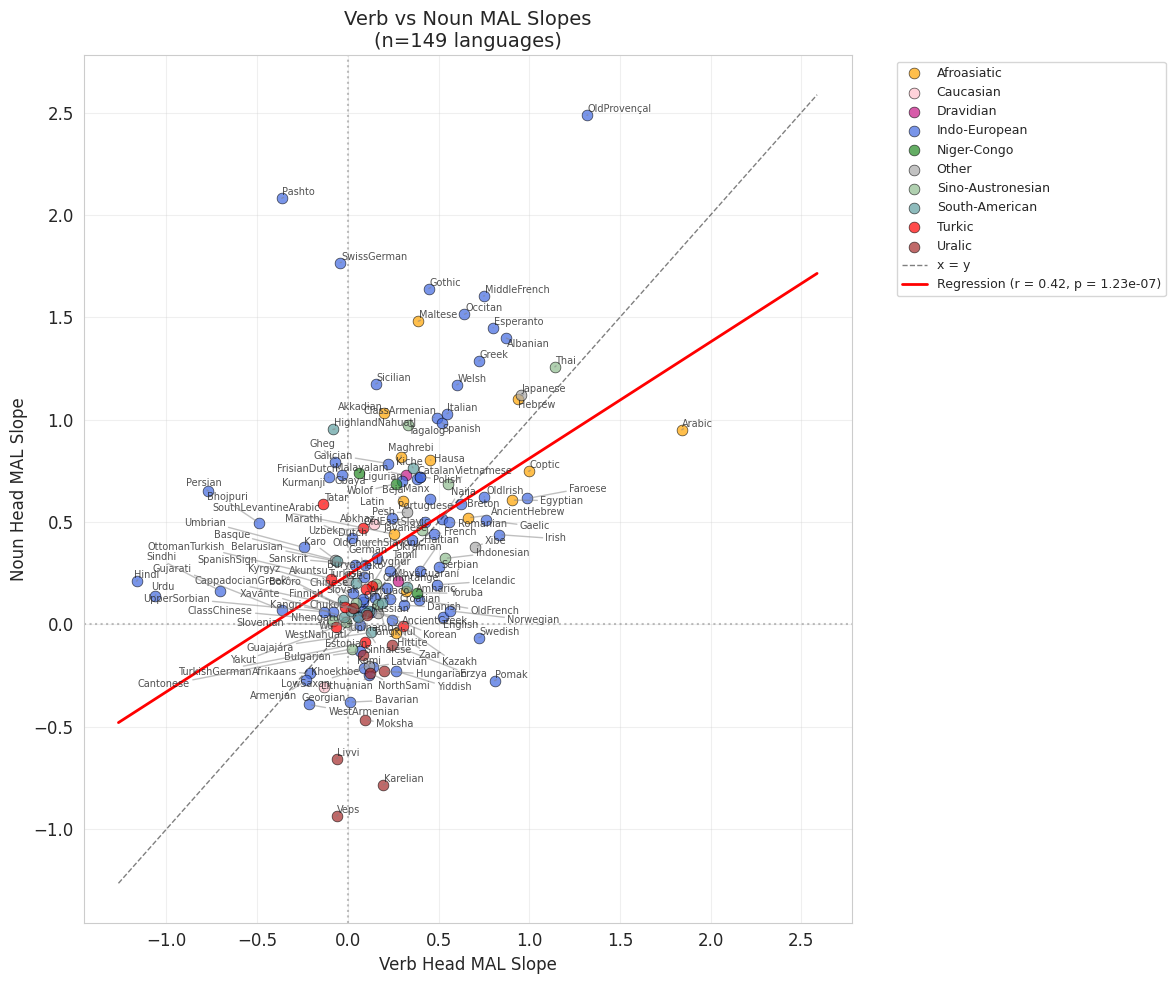

Saved: plots/mal_verb_vs_noun_by_group.png


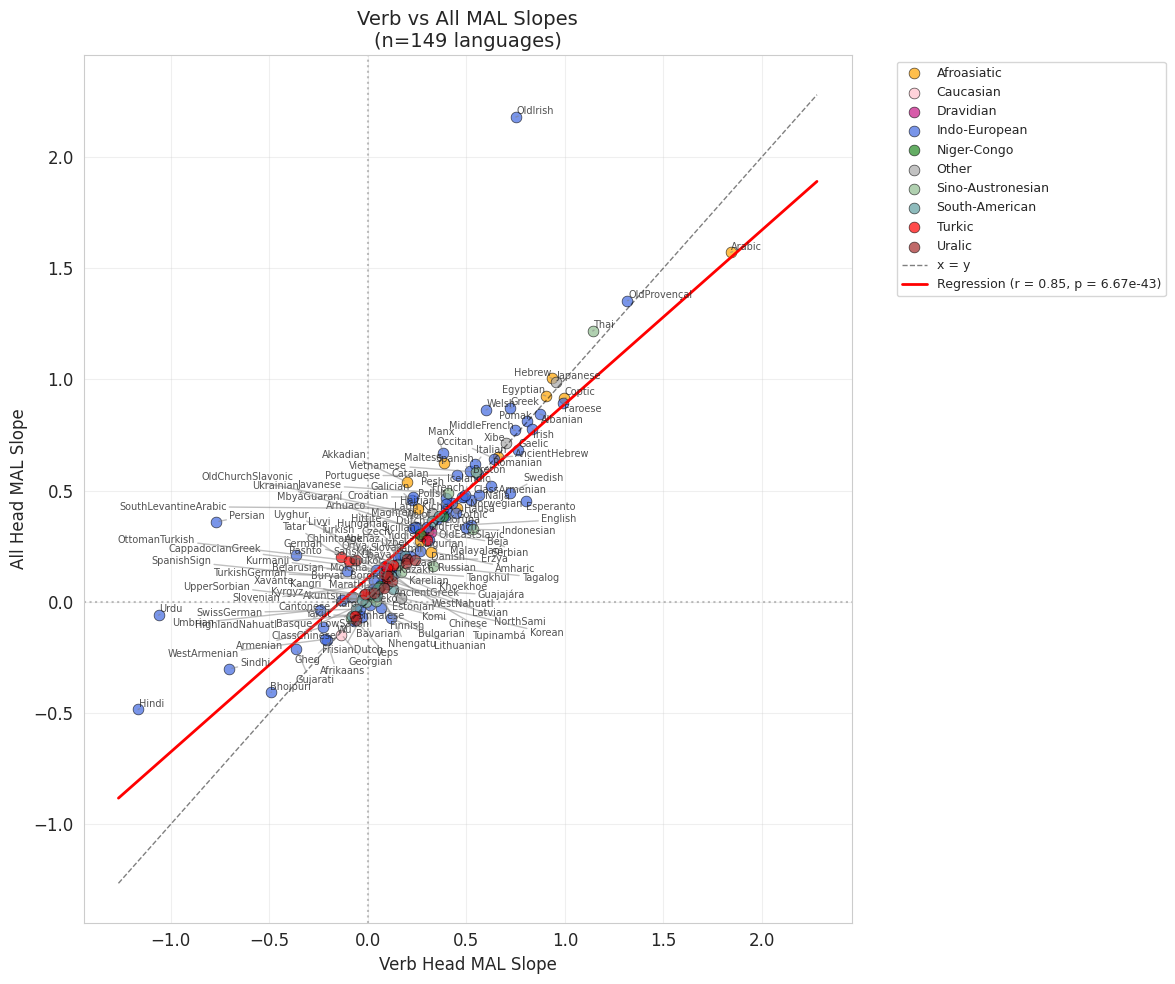

Saved: plots/mal_verb_vs_all_by_group.png


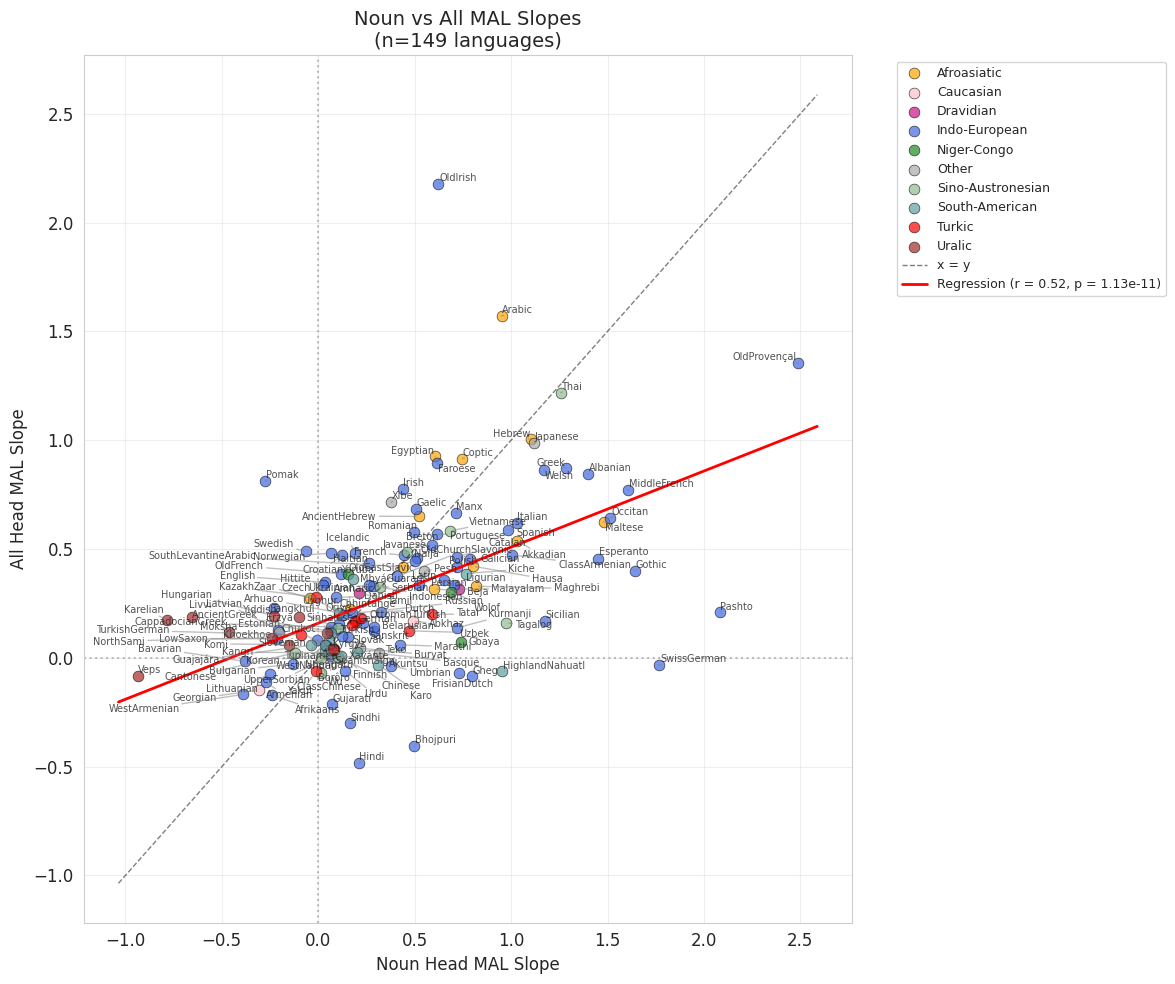

Saved: plots/mal_noun_vs_all_by_group.png


In [23]:
# Scatter plots: Verbal vs Nominal vs Joint MAL (separate figures with language labels)
from adjustText import adjust_text
import plotting

# Load appearance dict for colors (group -> color string)
appearance_dict = metadata.get('appearance_dict', {})

# Add group info to paired dataframe
df_paired['name'] = df_paired['lang'].map(langNames)
df_paired['group'] = df_paired['name'].map(metadata.get('langnameGroup', {}))
df_paired['group'] = df_paired['group'].fillna('Other')

# Create separate figures for each comparison
for ht1, ht2 in comparisons:
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Get unique groups and assign colors
    groups = df_paired['group'].unique()
    
    # Plot by group with colors
    texts = []
    for group in sorted(groups):
        subset = df_paired[df_paired['group'] == group]
        # appearance_dict maps group -> color string directly
        color = appearance_dict.get(group, '#888888')
        
        ax.scatter(subset[ht1], subset[ht2], 
                   c=color, label=group, s=60, alpha=0.7, edgecolors='black', linewidth=0.5)
        
        # Add text labels for each language
        for _, row in subset.iterrows():
            texts.append(ax.text(row[ht1], row[ht2], row['name'], 
                                 fontsize=7, alpha=0.8))
    
    # Adjust text to avoid overlapping
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))
    
    # Add diagonal line (x=y)
    lims = [min(df_paired[ht1].min(), df_paired[ht2].min()) - 0.1, 
            max(df_paired[ht1].max(), df_paired[ht2].max()) + 0.1]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1, label='x = y')
    
    # Add regression line
    slope, intercept, r_value, p_value, _ = stats.linregress(df_paired[ht1], df_paired[ht2])
    ax.plot(lims, [slope*l + intercept for l in lims], 'r-', linewidth=2,
            label=f'Regression (r = {r_value:.2f}, p = {p_value:.2e})')
    
    # Reference lines at 0
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
    
    # Labels and title
    ax.set_xlabel(f'{ht1.capitalize()} Head MAL Slope', fontsize=12)
    ax.set_ylabel(f'{ht2.capitalize()} Head MAL Slope', fontsize=12)
    ax.set_title(f'{ht1.capitalize()} vs {ht2.capitalize()} MAL Slopes\n(n={len(df_paired)} languages)', fontsize=14)
    
    # Legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'plots/mal_{ht1}_vs_{ht2}_by_group.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Saved: plots/mal_{ht1}_vs_{ht2}_by_group.png")

### Interpretation of Scatter Plots

#### Verb vs Noun MAL Slopes (r = 0.42)

The moderate correlation (r = 0.42) between verbal and nominal MAL slopes suggests that:
- Languages with steeper positive slopes for verbal heads also tend to have steeper positive slopes for nominal heads
- However, the relationship is not strong — a language's verbal MAL behavior only partially predicts its nominal MAL behavior
- **Nominal slopes are generally higher than verbal** (points above the diagonal), indicating that noun phrases show an even stronger "increasing size with distance" pattern

**Outliers of interest:**
- **Pashto**: Strong nominal MAL but near-zero verbal MAL — noun phrases show very different size patterns than verb phrases
- **Swiss German, Gothic**: Strong nominal effects with weak/negative verbal effects
- **Uralic languages** (Veps, Karelian, Livvi): Cluster with negative nominal slopes — potential true MAL in noun phrases

#### Verb vs All MAL Slopes (r = 0.85)

The high correlation (r = 0.85) indicates that:
- The **joint analysis is dominated by verbal patterns** — adding nominal heads doesn't substantially change the overall picture
- This is expected since verbs typically have more dependents than nouns in most sentences
- Languages cluster tightly around the regression line, suggesting verbal MAL is the primary driver

#### Noun vs All MAL Slopes (r = 0.52)

The moderate correlation shows:
- Nominal patterns contribute to but don't dominate the joint analysis
- **Arabic** is a notable outlier: strong nominal effect but the joint effect is lower, suggesting verbal patterns dampen the nominal tendency
- **Old Irish, Old Provençal**: Extreme outliers in the joint analysis

#### Language Family Patterns

- **Indo-European** (blue): Wide distribution, representing the diversity of this large family
- **Uralic** (brown): Tend toward lower/negative values — potential MAL compliance in this family
- **Turkic** (red): Generally positive slopes, anti-MAL pattern
- **Afroasiatic** (orange): Scattered, with Arabic as a high outlier

## 7. Summary Table

In [20]:
# Create summary table
summary_table = []

for ht in head_types:
    col = f'mal_{ht}'
    valid = df_mal[col].dropna()
    
    summary_table.append({
        'Head Type': ht.capitalize(),
        'N Languages': len(valid),
        'Mean Slope': f"{valid.mean():.4f}",
        'Std Slope': f"{valid.std():.4f}",
        '% Negative': f"{100*(valid < 0).mean():.1f}%",
        '% Significant': f"{sig_summary[ht]['pct_significant']:.1f}%",
        '% Sig Negative': f"{sig_summary[ht]['pct_sig_negative']:.1f}%",
        'Mean Effect Size': f"{sig_summary[ht]['mean_effect_size']:.2f}"
    })

df_summary = pd.DataFrame(summary_table)
print("\n" + "="*90)
print("SUMMARY: MAL EFFECT BY HEAD TYPE")
print("="*90)
print(df_summary.to_string(index=False))

# Save to CSV
df_summary.to_csv('data/mal_headtype_summary.csv', index=False)
print("\nSaved summary to data/mal_headtype_summary.csv")


SUMMARY: MAL EFFECT BY HEAD TYPE
Head Type  N Languages Mean Slope Std Slope % Negative % Significant % Sig Negative Mean Effect Size
     Verb          175     0.1994    0.3878      24.6%         10.9%           0.0%             0.68
     Noun          149     0.3738    0.5358      18.8%         10.1%           0.0%             0.83
      All          178     0.2438    0.3649      19.1%         12.9%           0.0%             0.85

Saved summary to data/mal_headtype_summary.csv


## 8. Conclusions

In [21]:
print("="*70)
print("CONCLUSIONS")
print("="*70)

# Compare verbal vs nominal
verb_pct = sig_summary['verb']['pct_sig_negative']
noun_pct = sig_summary['noun']['pct_sig_negative']
all_pct = sig_summary['all']['pct_sig_negative']

print(f"""
1. VERBAL HEADS (VERB):
   - {compliance_stats['verb']['pct_compliant']:.1f}% of languages show negative MAL slope
   - {verb_pct:.1f}% show SIGNIFICANT negative MAL
   - Mean effect size: {sig_summary['verb']['mean_effect_size']:.2f}

2. NOMINAL HEADS (NOUN/PROPN):
   - {compliance_stats['noun']['pct_compliant']:.1f}% of languages show negative MAL slope
   - {noun_pct:.1f}% show SIGNIFICANT negative MAL
   - Mean effect size: {sig_summary['noun']['mean_effect_size']:.2f}

3. JOINT (VERB + NOUN + PROPN):
   - {compliance_stats['all']['pct_compliant']:.1f}% of languages show negative MAL slope  
   - {all_pct:.1f}% show SIGNIFICANT negative MAL
   - Mean effect size: {sig_summary['all']['mean_effect_size']:.2f}

KEY FINDINGS:
""")

if verb_pct > noun_pct:
    print(f"  - Verbal MAL is stronger than nominal ({verb_pct:.1f}% vs {noun_pct:.1f}% significant)")
else:
    print(f"  - Nominal MAL is comparable to or stronger than verbal ({noun_pct:.1f}% vs {verb_pct:.1f}% significant)")

if all_pct > max(verb_pct, noun_pct):
    print(f"  - Joint analysis captures MORE significant languages ({all_pct:.1f}%)")
else:
    print(f"  - Joint analysis does not improve over individual analyses")

print(f"\n  - Correlation between verbal and nominal MAL across languages: r = {df_paired['verb'].corr(df_paired['noun']):.2f}")

CONCLUSIONS

1. VERBAL HEADS (VERB):
   - 24.6% of languages show negative MAL slope
   - 0.0% show SIGNIFICANT negative MAL
   - Mean effect size: 0.68

2. NOMINAL HEADS (NOUN/PROPN):
   - 18.8% of languages show negative MAL slope
   - 0.0% show SIGNIFICANT negative MAL
   - Mean effect size: 0.83

3. JOINT (VERB + NOUN + PROPN):
   - 19.1% of languages show negative MAL slope  
   - 0.0% show SIGNIFICANT negative MAL
   - Mean effect size: 0.85

KEY FINDINGS:

  - Nominal MAL is comparable to or stronger than verbal (0.0% vs 0.0% significant)
  - Joint analysis does not improve over individual analyses

  - Correlation between verbal and nominal MAL across languages: r = 0.42


## 9. Discussion: Position-from-Head vs Traditional MAL

### Key Observation

When measuring MAL using **position from head** (1st, 2nd, 3rd dependent), we observe:
- **Positive slopes** in most languages (mean ~0.2-0.4)
- **Anti-MAL pattern**: constituents further from the head are LARGER, not smaller
- **0% significant MAL compliance** across all head types

### Interpretation

This appears to contradict traditional MAL findings. However, the discrepancy likely stems from:

1. **Measure Definition**: Traditional MAL uses "sentence length" vs "word/constituent length". Here we use "position from head" vs "constituent span size".

2. **Linear Order Effects**: The first dependent of a verb is often a pronoun or short NP (close to head), while later dependents may include longer clauses (like relative clauses or adverbial phrases).

3. **Information Structure**: Topic/given information (often short) tends to appear closer to the head, while focus/new information (often longer) appears further away.

### Comparison of Head Types

| Head Type | Mean Slope | Correlation |
|-----------|------------|-------------|
| Verbal    | +0.20      | baseline    |
| Nominal   | +0.37      | r=0.42 with verbal |
| Joint     | +0.24      | r=0.85 with verbal |

- **Nominal heads show stronger positive slopes** than verbal heads (p < 0.01)
- This suggests noun phrases follow an even stronger "growing" pattern with distance from head
- Verbal and nominal effects are moderately correlated (r=0.42) across languages